In [1]:
import gc
import numpy as np
import pandas as pd
import networkx as nx
from pathlib import Path
import pycea as py
import sys
import scanpy as sc 
import seaborn as sns 
sys.path.append("/project/imoskowitz/yubin/Lineage_Tree_Construction")
from lineage_utilities.tree_functions import *

### Import Data

In [2]:
data_dir = "output_data"
plot_dir = "output_plot"
base_path = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_path_data = base_path+data_dir+"/Trees/Robin_Pijuan_celltypist/Manual_Cardiac_Annotation/E8_5/path_distance/"
output_path_plot = base_path+plot_dir+"/Trees/Robin_Pijuan_celltypist/Manual_Cardiac_Annotation/E8_5/path_distance/"

In [3]:
clone_key = 'E8.5-R1-C1'
color = "cardiac_labels"

In [17]:
tdata = td.read_h5td(base_path+'output_data/Processed_data/E8_5.h5td')

In [18]:
clone_tdata = tdata[tdata.obs["tree"] == clone_key]

In [4]:
clone_tdata = td.read_h5td(output_path_data+"temp/E8_5_r1_c1_with_path_distance.h5td")

### Pairwise Path Distance Analysis by celltype

In [9]:
palette = get_color_palette(clone_tdata, color_key=color)

add_obs_to_tree(clone_tdata, keys=[color, "germ_layer"])
py.pp.add_depth(clone_tdata)
py.tl.ancestral_states(clone_tdata, keys=color, tree=clone_key, method="mode")
flag_mixed_nodes(clone_tdata, clone_key, cell_type_key=color)
add_node_attrs_to_edges(clone_tdata, keys=[color, "germ_layer"])

In [15]:
tree_graph = clone_tdata.obst[clone_key]
leaf_order = py.get.leaves(clone_tdata, tree=clone_key)
n = len(leaf_order)

leaf_idx_map = {name: i for i, name in enumerate(clone_tdata.obs_names)}
leaf_indices = np.array([leaf_idx_map[l] for l in leaf_order])

cell_types = clone_tdata.obs.loc[leaf_order, color].astype(str).to_numpy()
valid_mask_leaf = ~np.isin(cell_types, ["nan", "None", "", "<NA>"])

In [7]:
# --- pairwise path distance (Adopted from lca analysis) ---
lca_depths = clone_tdata.obsp["path_distances"]
is_sparse = hasattr(lca_depths, "toarray")
if is_sparse:
    lca_depths = lca_depths.tocsr()

sub = lca_depths[leaf_indices, :][:, leaf_indices]
if is_sparse:
    sub = sub.toarray()

tri_i, tri_j = np.triu_indices(n, k=1)
pair_depths = sub[tri_i, tri_j]
valid_pair = valid_mask_leaf[tri_i] & valid_mask_leaf[tri_j]

same_type = cell_types[tri_i] == cell_types[tri_j]
same_mean = pair_depths[same_type & valid_pair].mean() if (same_type & valid_pair).any() else np.nan
diff_mean = pair_depths[~same_type & valid_pair].mean() if (~same_type & valid_pair).any() else np.nan
observed_diff = same_mean - diff_mean

IndexError: arrays used as indices must be of integer (or boolean) type

In [ ]:
def plot_mean_distances(adata, obsp_key='distances', celltype_key='cell_type'):
    # Extract the distance matrix from AnnData
    dist_matrix = adata.obsp[obsp_key]
    if hasattr(dist_matrix, "toarray"):
        dist_matrix = dist_matrix.toarray()
        
    # Get categorical labels
    celltypes = adata.obs[celltype_key].values
    categories = adata.obs[celltype_key].cat.categories
    
    # Calculate group-level average distances
    df = pd.DataFrame(dist_matrix)
    mean_dist = df.groupby(celltypes).mean().T.groupby(celltypes).mean()
    
    # Ensure correct index and column sorting
    mean_dist.index = categories
    mean_dist.columns = categories
    
    return mean_dist

# Generate the mean distance dataframe
mean_distance_df = plot_mean_distances(clone_tdata, obsp_key='path_distances', celltype_key=color)

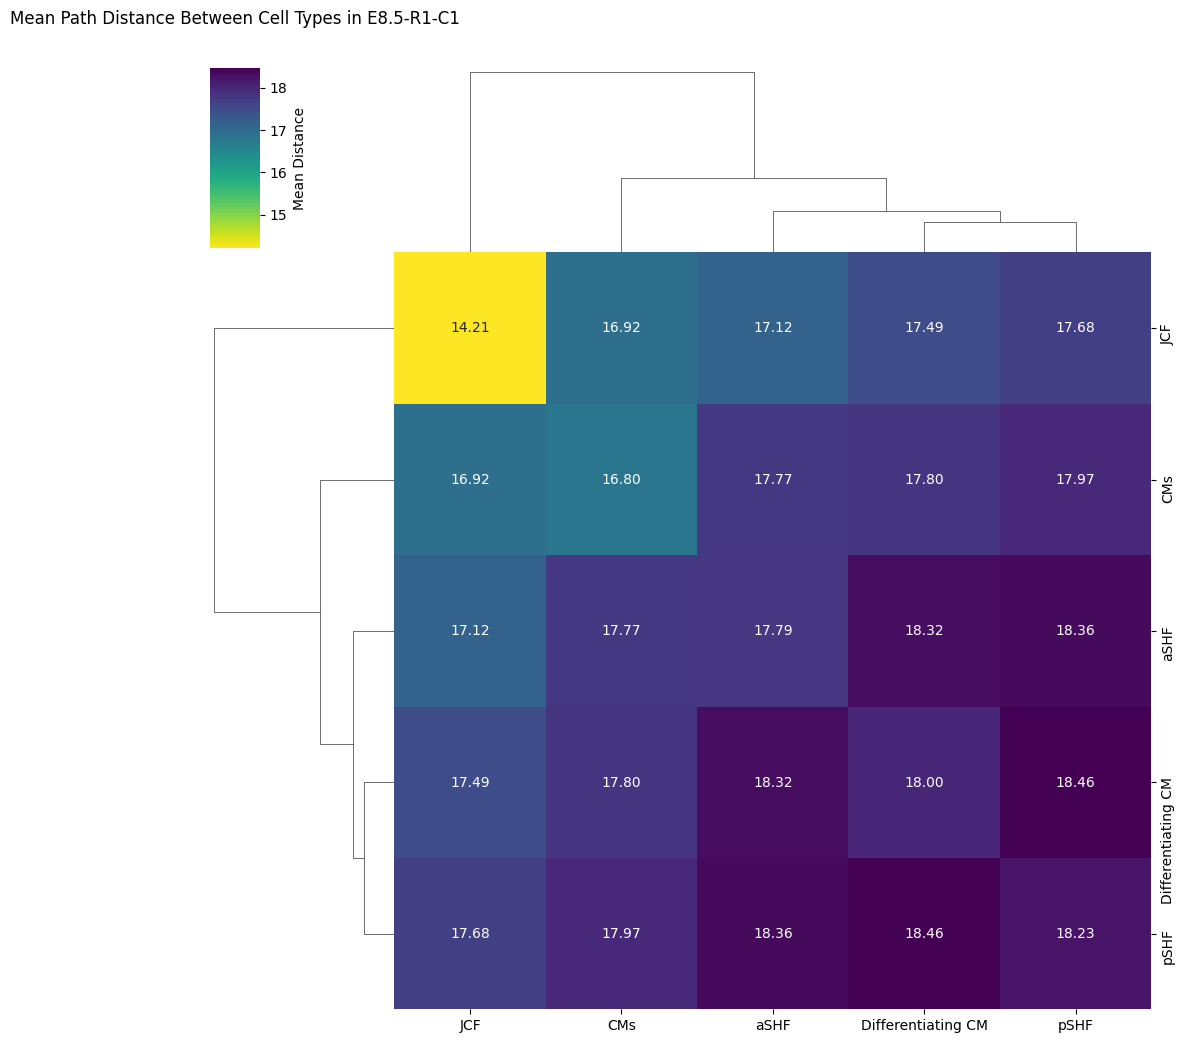

In [ ]:
# Visualize using a Seaborn clustered heatmap
g = sns.clustermap(
    mean_distance_df, 
    cmap='viridis_r',      # Inverted viridis so that closer distances are brighter
    annot=True,            # Show exact distance numbers inside cells
    fmt=".2f",             # Round numbers to two decimal places
    cbar_kws={'label': 'Mean Distance'}
)

plt.title('Mean Path Distance Between Cell Types in '+clone_key, y=1.2)
plt.savefig(output_path_plot+"mean_path_distance_heatmap_E8_R1_C1.png")
plt.show()

/scratch/local/jobs/52458132/ipykernel_327093/537444722.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_dist = df_temp.groupby(celltypes).mean().T.groupby(celltypes).mean()
/scratch/local/jobs/52458132/ipykernel_327093/537444722.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_dist = df_temp.groupby(celltypes).mean().T.groupby(celltypes).mean()


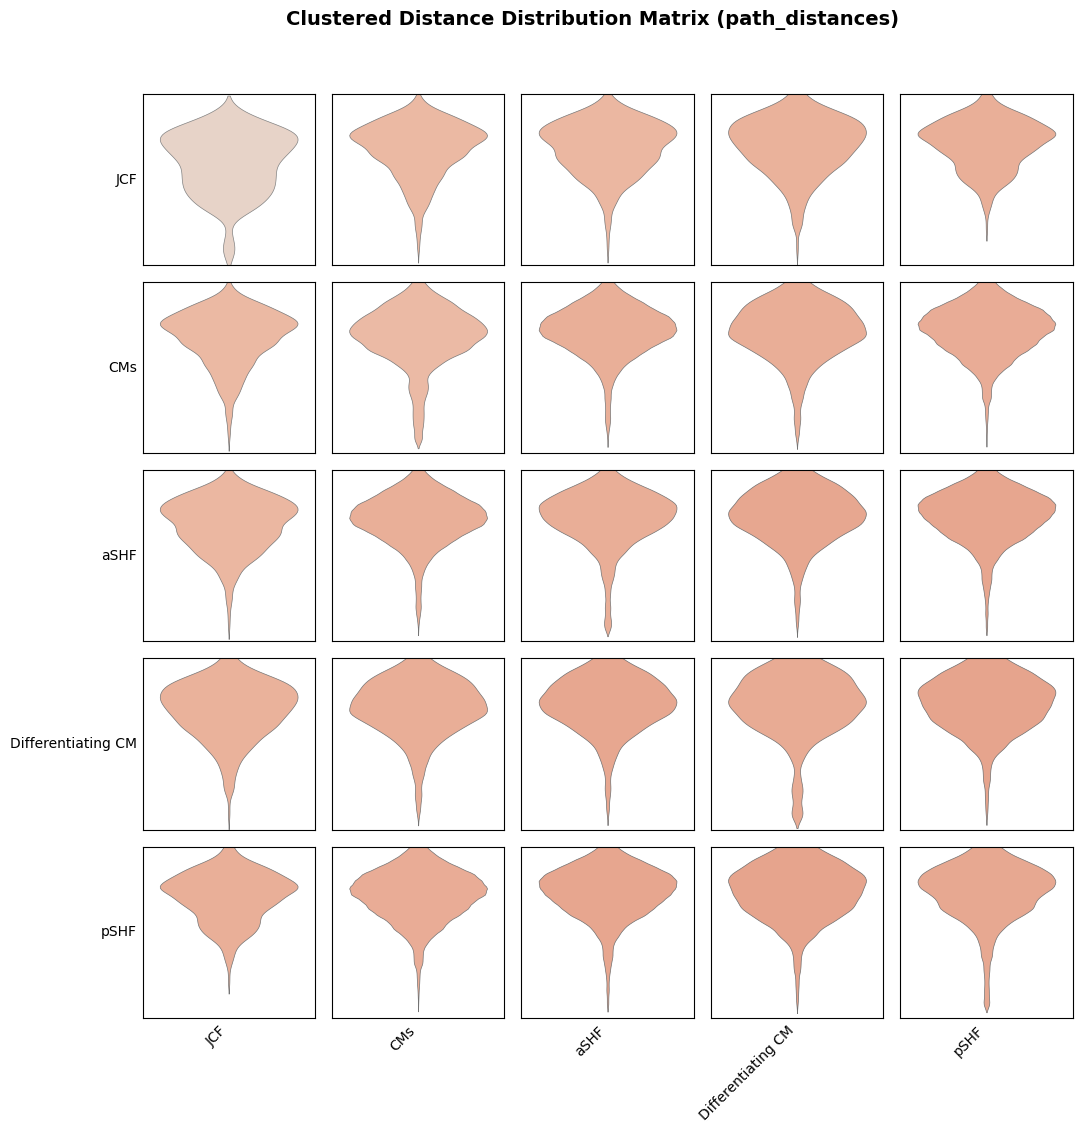

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import linkage, dendrogram

def plot_clustered_violin_matrix(adata, obsp_key='distances', celltype_key='cell_type', figsize=(12, 12)):
    # 1. Extract distances and metadata
    dist_matrix = adata.obsp[obsp_key]
    if hasattr(dist_matrix, "toarray"):
        dist_matrix = dist_matrix.toarray()
        
    celltypes = adata.obs[celltype_key].values
    categories = list(adata.obs[celltype_key].cat.categories)
    n_cats = len(categories)
    
    # 2. Compute a mean matrix strictly to calculate hierarchical clustering order
    df_temp = pd.DataFrame(dist_matrix)
    mean_dist = df_temp.groupby(celltypes).mean().T.groupby(celltypes).mean()
    mean_dist = mean_dist.loc[categories, categories].values
    
    # Run linkage clustering
    Z = linkage(mean_dist, method='ward')
    dendro = dendrogram(Z, no_plot=True)
    leaves_idx = dendro['leaves']
    
    # Reorder categories based on clustering tree
    ordered_categories = [categories[i] for i in leaves_idx]
    
    # 3. Create the multi-panel GridSpec layout
    # Leaves space for the top/left dendrograms if you wish to expand, or a clean grid
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(n_cats, n_cats, wspace=0.1, hspace=0.1)
    
    # Color palette matching matrix positions
    colors = sns.color_palette("coolwarm", as_cmap=True)
    global_max = np.percentile(dist_matrix, 99) # Clip outliers for prettier violin limits
    
    # 4. Populate each grid cell with a violin plot
    for i, row_ct in enumerate(ordered_categories):
        for j, col_ct in enumerate(ordered_categories):
            
            # Mask matrix to find distances between row_ct and col_ct
            row_mask = (celltypes == row_ct)
            col_mask = (celltypes == col_ct)
            
            # Sub-select distances between these two groups
            sub_dist = dist_matrix[row_mask][:, col_mask].flatten()
            
            # Remove exact 0 self-distances if looking at the same cell group diagonal
            if row_ct == col_ct:
                sub_dist = sub_dist[sub_dist > 0]
                
            # Initialize sub-plot cell
            ax = fig.add_subplot(gs[i, j])
            
            if len(sub_dist) > 0:
                # Plot the individual distribution
                # Inner=None keeps the tiny grid squares clean
                sns.violinplot(
                    y=sub_dist, ax=ax, color=colors(mean_dist[leaves_idx[i], leaves_idx[j]] / global_max),
                    orient='v', inner=None, linewidth=0.5
                )
            
            # Clean boundaries and set uniform y-axis scaling across the matrix
            ax.set_ylim(0, global_max)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.set_ylabel('')
            
            # Label the outer left edge of the matrix grid
            if j == 0:
                ax.set_ylabel(row_ct, rotation=0, ha='right', va='center', fontsize=10)
            # Label the outer bottom edge of the matrix grid
            if i == n_cats - 1:
                ax.set_xlabel(col_ct, rotation=45, ha='right', fontsize=10)
                
    plt.suptitle(f"Clustered Distance Distribution Matrix ({obsp_key}) for {clone_key}", y=0.95, fontsize=14, weight='bold')
    plt.show()

# Run the visualization pipeline
plot_clustered_violin_matrix(clone_tdata, obsp_key='path_distances', celltype_key=color)


#### Heatmap of pairwise distance grouped by celltype

In [5]:
from matplotlib.patches import Patch
 
 
def plot_distance_heatmap_grouped(
    tdata, groupby, distance_key="tree_distances", cmap="viridis",
    palette=None, figsize=(8, 8), **clustermap_kwargs,
):
    """
    Plot the full pairwise path_distance matrix as a heatmap, with cells
    sorted by `groupby` and a color strip marking group membership.
 
    Parameters
    ----------
    tdata : treedata.TreeData
    groupby : str
        Column in `tdata.obs` to group/order cells by (e.g. "celltype").
    distance_key : str, default "tree_distances"
        The `obsp` key where `pycea.tl.tree_distance` stored distances.
    cmap : str, default "viridis"
        Colormap for the distance values.
    palette : dict, optional
        Mapping from group value -> color. Defaults to a seaborn "Set2"
        palette generated from the observed categories.
    figsize : tuple, default (8, 8)
    **clustermap_kwargs
        Passed through to `seaborn.clustermap` (e.g. `vmin`, `vmax`).
 
    Returns
    -------
    seaborn.matrix.ClusterGrid
        The clustermap object (rows/columns are NOT reclustered --
        `row_cluster`/`col_cluster` are forced to False so the ordering
        stays grouped-by-`groupby`, not hierarchically reordered).
    """
    mat = tdata.obsp[distance_key]
    df = pd.DataFrame(mat, index=tdata.obs_names, columns=tdata.obs_names)
 
    order = tdata.obs.sort_values(groupby).index
    df_ordered = df.loc[order, order]
    groups = tdata.obs.loc[order, groupby]
 
    if palette is None:
        cats = groups.astype("category").cat.categories
        palette = dict(zip(cats, sns.color_palette("Set2", len(cats))))
    group_colors = groups.map(palette)
 
    clustermap_kwargs.setdefault("cbar_kws", {"label": "path_distance"})
    g = sns.clustermap(
        df_ordered,
        row_cluster=False, col_cluster=False,
        row_colors=group_colors, col_colors=group_colors,
        cmap=cmap, figsize=figsize,
        **clustermap_kwargs,
    )
    g.ax_heatmap.set_xticks([])
    g.ax_heatmap.set_yticks([])
    g.ax_heatmap.set_xlabel("cells")
    g.ax_heatmap.set_ylabel("cells")
 
    handles = [Patch(color=palette[val], label=val) for val in groups.unique()]
    g.ax_heatmap.legend(handles=handles, title=groupby, bbox_to_anchor=(1.25, 1), loc="upper left")
 
    return g

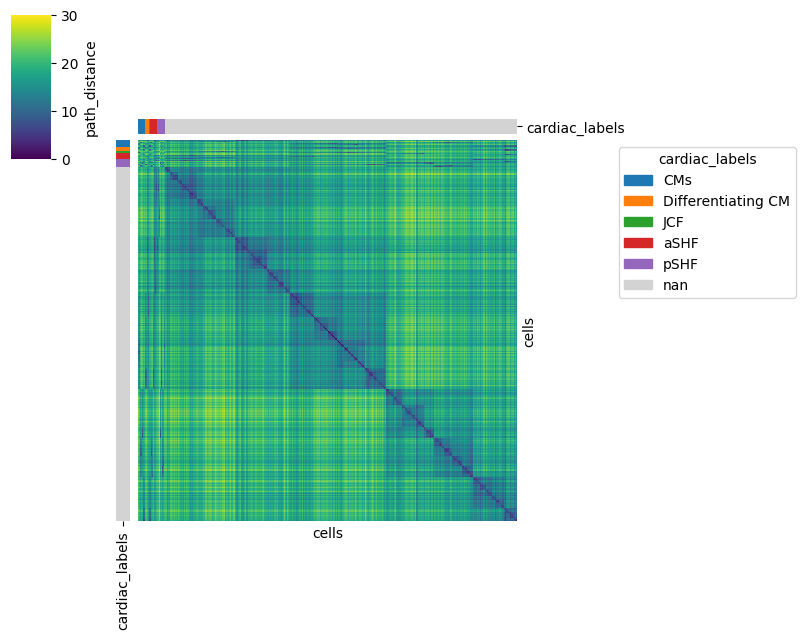

In [10]:
g = plot_distance_heatmap_grouped(clone_tdata, groupby=color, distance_key='path_distances', palette=palette)
g.savefig("path_distance_heatmap_grouped_by_celltype.png", dpi=150, bbox_inches="tight")

In [14]:
clone_tdata

TreeData object with n_obs × n_vars = 6192 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20', 'cardiac_labels', 'depth'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_labe

In [17]:
cell_types

array(['nan', 'nan', 'nan', ..., 'nan', 'nan', 'nan'], dtype=object)

In [16]:
# remove cells that are not cardiac labeled and graphing heatmap based only on that
cardiac_tdata = clone_tdata[clone_tdata.obs[color].isin(cell_types)]
cardiac_tdata

View of TreeData object with n_obs × n_vars = 447 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20', 'cardiac_labels', 'depth'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_

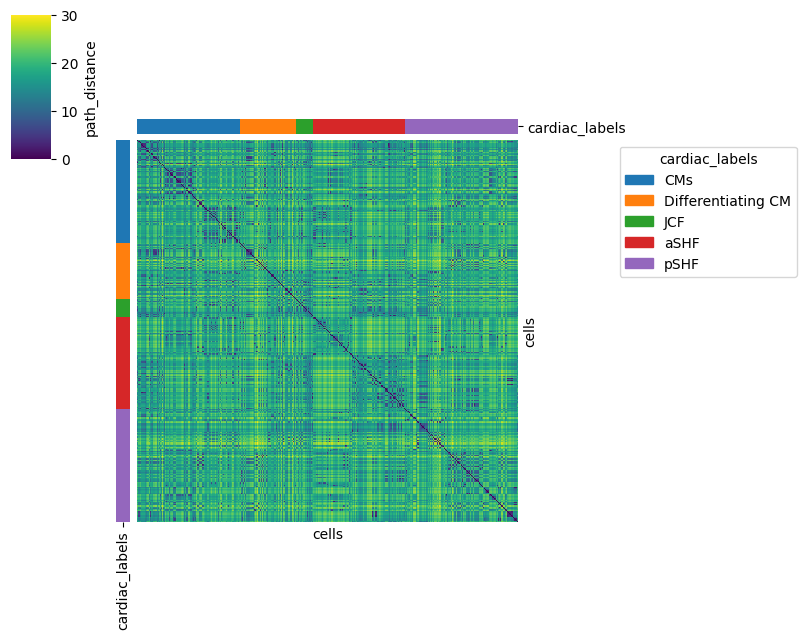

In [20]:
h = plot_distance_heatmap_grouped(cardiac_tdata, groupby=color, distance_key='path_distances', palette=palette)
h.savefig(output_path_plot+"path_distance_heatmap_cardiac_cell_only.png", dpi=150, bbox_inches="tight")

In [8]:
py.pp.add_depth(clone_tdata)


In [15]:
clone_tdata

TreeData object with n_obs × n_vars = 6192 × 78258
    obs: 'cell_subtype', 'capture', 'embryo', 'stage', 'type', 'total_counts', 'pe_counts', 'detection_rate', 'edit_frac', 'clone', 'phase', 'cell_type', 'germ_layer', 'lineage', 'tree', 'leiden_0.25', 'leiden_0.5', 'leiden_1.0', 'leiden_2.0', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label', 'Robin_Pijuan_annotation_E8_5_model_top1000_low_score', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l025', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l05', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l10', 'Robin_Pijuan_annotation_E8_5_model_top1000_mv_label_mode_l20', 'cardiac_labels', 'depth'
    var: 'gene_ids', 'mito', 'chromosome'
    uns: 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_label_colors', 'Cardio-mesodermal_atlas_formatted_E85_model_top1000_mv_labe

In [12]:
from matplotlib.gridspec import GridSpec


In [21]:
palette = get_color_palette(clone_tdata, color_key=color)

add_obs_to_tree(clone_tdata, keys=[color, "germ_layer"])
py.pp.add_depth(clone_tdata)
py.tl.ancestral_states(clone_tdata, keys=color, tree=clone_key, method="mode")
flag_mixed_nodes(clone_tdata, clone_key, cell_type_key=color)
add_node_attrs_to_edges(clone_tdata, keys=[color, "germ_layer"])

<Axes: title={'center': 'Lineage tree — E8.5-R1-C1'}>

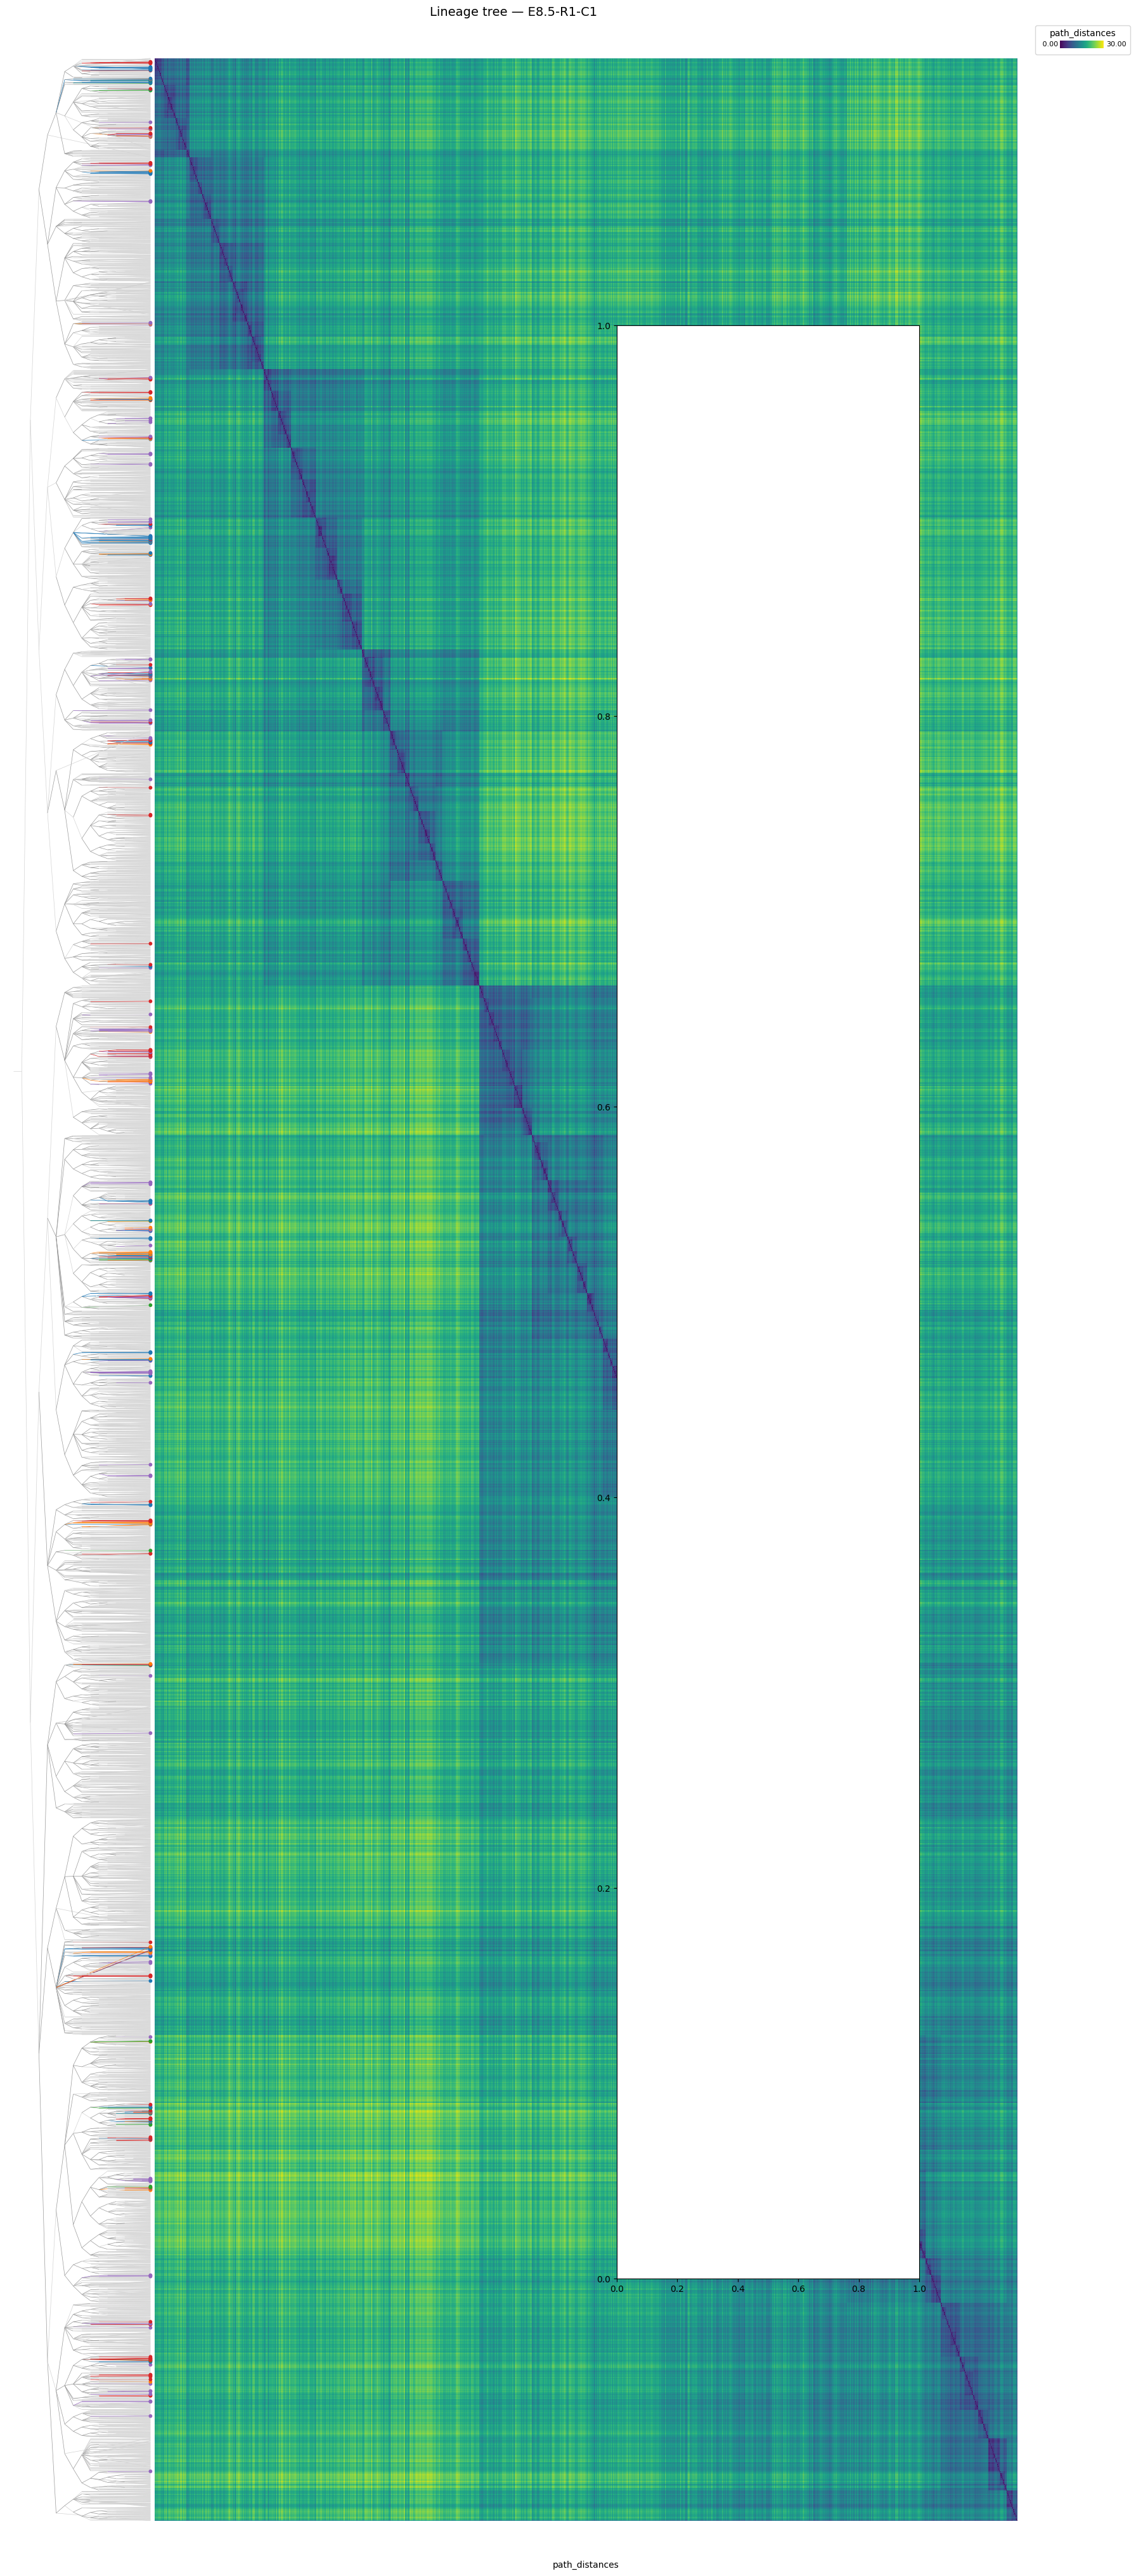

In [28]:
# Create a tree panel and a right-side point panel
fig = plt.figure(figsize=(16, 40))
#gs = GridSpec(1, @, width_ratios=[3, 2], wspace=0.08)
ax_tree = fig.add_subplot((0,0,1,1))
#ax_points = fig.add_subplot(gs[1])
py.pl.branches(
    clone_tdata,
    depth_key="depth",
    color=color,
    palette=palette,
    extend_branches=True,
    angled_branches=True,
    tree=clone_key,
    legend=False,
    ax=ax_tree,
)
py.pl.nodes(
    clone_tdata,
    color=color,
    palette=palette,
    nodes="leaves",
    size=10,
    legend=False,
    tree=clone_key,
    ax=ax_tree,
)
ax_tree.set_title(f"Lineage tree — {clone_key}", fontsize=14)
py.pl.annotation(clone_tdata, keys="path_distances", ax=ax_tree)

In [29]:
def tag_celltype_path(tdata, celltype_key, target, tree="tree", key_added=None):
    """
    Tag every edge on the path from the root to each leaf of `target`
    celltype, so it can be colored with `pycea.pl.branches`.
 
    Parameters
    ----------
    tdata : treedata.TreeData
    celltype_key : str
        Column in `tdata.obs` holding the celltype labels.
    target : Any
        The specific celltype value to highlight.
    tree : str, default "tree"
        The `obst` key of the tree to use.
    key_added : str, optional
        Edge attribute name to store the tag under.
        Defaults to f"{celltype_key}_path".
 
    Returns
    -------
    str
        The edge attribute key that was added -- pass this straight to
        `pycea.pl.branches(tdata, color=key)`.
    """
    key_added = key_added or f"{celltype_key}_path"
    G = tdata.obst[tree]
    root = next(n for n in G.nodes if G.in_degree(n) == 0)
 
    target_leaves = tdata.obs_names[tdata.obs[celltype_key] == target]
    missing = [leaf for leaf in target_leaves if leaf not in G.nodes]
    if missing:
        raise ValueError(f"{len(missing)} labeled cells are not nodes in tree '{tree}', e.g. {missing[:3]}")
 
    edges_on_path = set()
    for leaf in target_leaves:
        path = nx.shortest_path(G, root, leaf)  # tree is a DAG rooted at `root`, so root->leaf is direct
        edges_on_path.update(zip(path[:-1], path[1:]))
 
    for u, v in G.edges():
        G[u][v][key_added] = target if (u, v) in edges_on_path else None
 
    return key_added
 

<PolarAxes: >

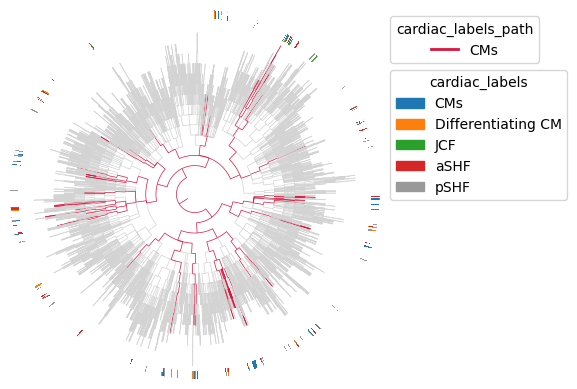

In [33]:
key = tag_celltype_path(clone_tdata, celltype_key="cardiac_labels", tree=clone_key, target="CMs")

py.pl.branches(clone_tdata, color=key, na_color="lightgrey", palette={"CMs": "crimson"}, polar=True)
py.pl.annotation(clone_tdata, keys="cardiac_labels")   # optional: leaf strip alongside, for reference

In [59]:
import scipy.sparse as sp
def _get_pair_distance(tdata, cell_a, cell_b, distance_key="tree_distances"):
    """Pull tdata.obsp[distance_key][cell_a, cell_b], handling sparse or dense storage."""
    mat = tdata.obsp[distance_key]
    i = tdata.obs_names.get_loc(cell_a)
    j = tdata.obs_names.get_loc(cell_b)
    val = mat[i, j]
    if sp.issparse(mat):
        val = val if np.isscalar(val) else val.toarray()[0, 0]
    return float(val)
 
 
def highlight_pair_path(
    tdata, cell_a, cell_b, tree="tree", distance_key="tree_distances",
    key_added=None, linewidth_key_added=None, highlight_width=3.0, base_width=0.5,
    verbose=True,
):
    """
    Print the stored path_distance between two cells and tag the edges
    connecting them so the path can be colored (and thickened) with
    `pycea.pl.branches`.
 
    Parameters
    ----------
    tdata : treedata.TreeData
    cell_a, cell_b : str
        Cell IDs -- must match entries in `tdata.obs_names` and be nodes
        in the tree.
    tree : str, default "tree"
        The `obst` key of the tree to use.
    distance_key : str, default "tree_distances"
        The `obsp` key where `pycea.tl.tree_distance` stored distances
        (this is `f"{key_added}_distances"` from that call -- default
        `key_added` there is `'tree'`, giving `'tree_distances'`).
    key_added : str, optional
        Edge attribute name to store the color tag under.
        Defaults to f"path_{cell_a}_{cell_b}".
    linewidth_key_added : str, optional
        Edge attribute name to store the linewidth tag under.
        Defaults to f"{key_added}_width".
    highlight_width : float, default 3.0
        Linewidth for edges on the path.
    base_width : float, default 0.5
        Linewidth for every other edge.
    verbose : bool, default True
        Print the distance that was looked up.
 
    Returns
    -------
    (distance, color_key, width_key) : (float, str, str)
        The stored path_distance for this pair, and the edge attribute
        keys to pass to
        `pycea.pl.branches(tdata, color=color_key, linewidth=width_key)`.
    """
    G = tdata.obst[tree]
    if cell_a not in G.nodes or cell_b not in G.nodes:
        raise ValueError(f"{cell_a!r} and/or {cell_b!r} are not nodes in tree {tree!r}")
 
    dist = _get_pair_distance(tdata, cell_a, cell_b, distance_key)
    if verbose:
        print(f"path_distance({cell_a}, {cell_b}) = {dist}  [from tdata.obsp[{distance_key!r}]]")
 
    # path between the two leaves, found on the undirected view since the
    # stored tree only has parent -> child edges
    path_nodes = nx.shortest_path(G.to_undirected(), cell_a, cell_b)
    path_edges = set(zip(path_nodes[:-1], path_nodes[1:])) | set(zip(path_nodes[1:], path_nodes[:-1]))
 
    key_added = key_added or f"path_{cell_a}_{cell_b}"
    linewidth_key_added = linewidth_key_added or f"{key_added}_width"
    label = f"{cell_a} \u2194 {cell_b}"
    for u, v in G.edges():
        on_path = (u, v) in path_edges
        G[u][v][key_added] = label if on_path else None
        G[u][v][linewidth_key_added] = highlight_width if on_path else base_width
 
    return dist, key_added, linewidth_key_added
 

In [60]:
CMs_cells = clone_tdata[clone_tdata.obs[color]=='CMs'].obs_names

path_distance(E8.5-R1-T2-CTTCTATGTCTGTCCT-1, E8.5-R1-T1-TCGGTTAAGTAGGACG-1) = 17.0  [from tdata.obsp['path_distances']]


<Axes: >

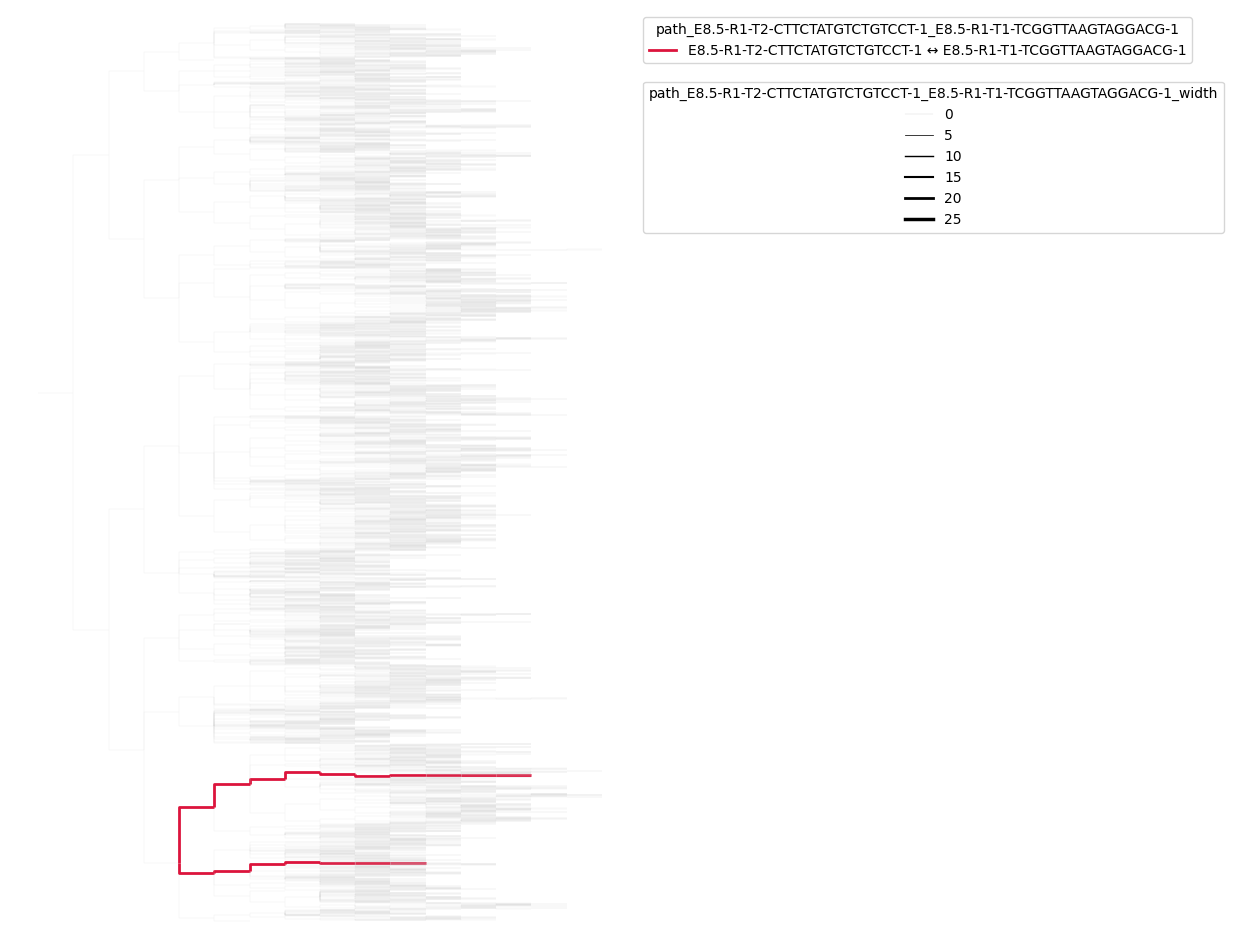

In [66]:
cell_a = CMs_cells[1]   # or whatever two indices you have
cell_b = CMs_cells[4]

dist, color_key, width_key = highlight_pair_path(
    clone_tdata, cell_a, cell_b,
    highlight_width=20.0,   # thickness on the path
    base_width=0.5,        # thickness everywhere else
    tree=clone_key,
    distance_key='path_distances'
)
# prints: path_distance(cell_a, cell_b) = <value>  [from tdata.obsp['tree_distances']]
fig, ax = plt.subplots(figsize=(8, 12))

py.pl.branches(
    clone_tdata,
    color=color_key,
    linewidth=width_key,
    na_color="lightgrey",
    palette={f"{cell_a} ↔ {cell_b}": "crimson"},
    ax=ax
)